# Libraries

In [30]:
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import MinMaxScaler
import pickle
import os

# Load Data

In [31]:
print("📂 Loading Data...")
content_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\content.csv")
interactions_df = pd.read_csv(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\interactions.csv")
users_df = pd.read_excel(r"E:\faculty\Ma'man\recommendation_system\Recommendation-System-2\data\users.xlsx")

print(f"✅ Content: {content_df.shape[0]} items")
print(f"✅ Interactions: {interactions_df.shape[0]} ratings")
print(f"✅ Users: {users_df.shape[0]} users")

📂 Loading Data...
✅ Content: 2000 items
✅ Interactions: 200000 ratings
✅ Users: 5000 users


In [32]:
def clean_data(df):
    """تنظيف البيانات من القيم المفقودة والتكرارات"""
    # إزالة التكرارات
    df = df.drop_duplicates()
    
    # التعامل مع القيم المفقودة
    if 'description' in df.columns:
        df['description'] = df['description'].fillna('No description')
    if 'category' in df.columns:
        df['category'] = df['category'].fillna('Uncategorized')
    if 'level' in df.columns:
        df['level'] = df['level'].fillna('Beginner')
    
    return df

content_df = clean_data(content_df)
interactions_df = clean_data(interactions_df)

# Content Embeddings

In [33]:
model = SentenceTransformer('all-MiniLM-L6-v2')

content_df['text'] = (
    content_df['title'].astype(str) + " " +
    content_df['category'].astype(str) + " " +
    content_df['level'].astype(str) + " " +
    content_df['description'].astype(str)
)

content_embeddings = model.encode(content_df['text'].tolist())

content_sim = cosine_similarity(content_embeddings)

# RETRAIN FUNCTION (SVD)

In [34]:
def retrain_collaborative(interactions_df):

    print("🔁 Retraining Collaborative Model...")

    user_item = interactions_df.pivot_table(
        index='user_id',
        columns='content_id',
        values='rating',
        fill_value=0
    )

    svd = TruncatedSVD(n_components=50, random_state=42)

    user_factors = svd.fit_transform(user_item)
    item_factors = svd.components_

    collab_pred = np.dot(user_factors, item_factors)

    collab_df = pd.DataFrame(
        collab_pred,
        index=user_item.index,
        columns=user_item.columns
    )

    print("✅ Retraining Done!")

    return collab_df, user_item

# Initial Training

In [35]:
collab_df, user_item = retrain_collaborative(interactions_df)

🔁 Retraining Collaborative Model...
✅ Retraining Done!


# Hybrid Recommendation

In [36]:
def hybrid_recommend(user_id, collab_df, top_n=5):

    all_items = content_df['content_id'].values

    # ---------- Content Score ----------
    content_scores = pd.Series(0, index=all_items, dtype=float)

    history = interactions_df[
        interactions_df['user_id'] == user_id
    ]['content_id'].values

    idx = content_df[content_df['content_id'].isin(history)].index

    if len(idx) > 0:
        scores = np.sum(content_sim[idx], axis=0)
        content_scores = pd.Series(scores, index=all_items)

    # ---------- Collaborative Score ----------
    if user_id in collab_df.index:
        collab_scores = collab_df.loc[user_id].reindex(all_items, fill_value=0)
    else:
        collab_scores = pd.Series(0, index=all_items)

    # ---------- Normalization ----------
    scaler = MinMaxScaler()

    content_norm = scaler.fit_transform(
        content_scores.values.reshape(-1,1)
    ).flatten()

    collab_norm = scaler.fit_transform(
        collab_scores.values.reshape(-1,1)
    ).flatten()

    # ---------- Final Score ----------
    final_score = 0.5 * content_norm + 0.5 * collab_norm

    result = pd.DataFrame({
        "content_id": all_items,
        "score": final_score
    })

    result = result.merge(content_df, on="content_id")
    result = result.sort_values("score", ascending=False)

    return result.head(top_n)

# evaluate

In [37]:
def evaluate_model(collab_df):

    users = interactions_df['user_id'].unique()[:50]

    precisions, recalls, f1s = [], [], []

    for u in users:

        recs = hybrid_recommend(u, collab_df)['content_id'].tolist()

        actual = interactions_df[
            (interactions_df['user_id'] == u) &
            (interactions_df['rating'] >= 3)
        ]['content_id'].tolist()

        if len(actual) == 0:
            continue

        k = 5

        precision = len(set(recs[:k]) & set(actual)) / k
        recall = len(set(recs[:k]) & set(actual)) / len(actual)

        f1 = 0 if (precision + recall) == 0 else 2*(precision*recall)/(precision+recall)

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)

    return np.mean(precisions), np.mean(recalls), np.mean(f1s)

#  BEFORE RETRAIN

In [38]:
collab_before = collab_df.copy()

before_metrics = evaluate_model(collab_before)

# BIG DATA SIMULATION (Optional)

In [39]:
new_data = pd.DataFrame({
    "user_id": np.random.randint(1, 500, 20000),
    "content_id": np.random.randint(1, 200, 20000),
    "rating": np.random.randint(1, 6, 20000)
})

interactions_updated = pd.concat([interactions_df, new_data])

# AFTER RETRAIN


In [40]:
collab_after, user_item_after = retrain_collaborative(interactions_updated)

after_metrics = evaluate_model(collab_after)

🔁 Retraining Collaborative Model...
✅ Retraining Done!


# RESULTS COMPARISON

In [41]:
print("📊 BEFORE RETRAIN")
print("Precision:", before_metrics[0])
print("Recall:", before_metrics[1])
print("F1:", before_metrics[2])

print("\n📊 AFTER RETRAIN")
print("Precision:", after_metrics[0])
print("Recall:", after_metrics[1])
print("F1:", after_metrics[2])


📊 BEFORE RETRAIN
Precision: 0.7639999999999999
Recall: 0.08926007605710964
F1: 0.1531235983384351

📊 AFTER RETRAIN
Precision: 0.7560000000000001
Recall: 0.09011211885979828
F1: 0.15387118251875065


# PLOT COMPARISON

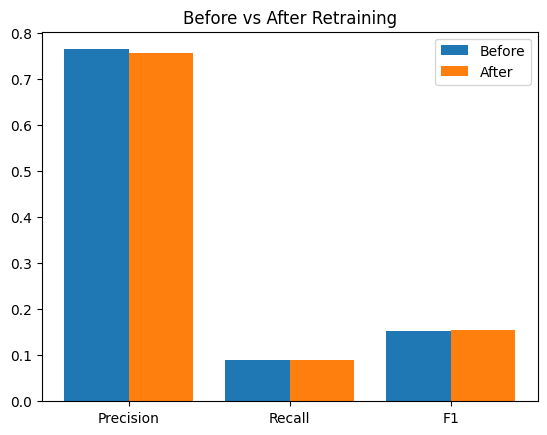

In [42]:
import matplotlib.pyplot as plt

labels = ["Precision", "Recall", "F1"]

plt.bar(np.arange(3)-0.2, before_metrics, 0.4, label="Before")
plt.bar(np.arange(3)+0.2, after_metrics, 0.4, label="After")

plt.xticks(np.arange(3), labels)
plt.title("Before vs After Retraining")
plt.legend()
plt.show()

# TEST RECOMMENDATION

In [43]:
print(hybrid_recommend(1, collab_after))

      content_id     score                           title  \
170          171  0.850603   Deep Learning with TensorFlow   
137          138  0.804901  Introduction to Cyber Security   
1970        1971  0.704714            Python for Beginners   
25            26  0.667649  Introduction to Cyber Security   
1010        1011  0.623162  Introduction to Cyber Security   

                                            description         category  \
170   Beginner-friendly course covering core concept...  Cloud Computing   
137   Step-by-step guide to becoming a professional ...     Data Science   
1970  Advanced course for professionals aiming to up...   Cyber Security   
25    Advanced course for professionals aiming to up...   Cyber Security   
1010  Advanced course for professionals aiming to up...  Cloud Computing   

             level  duration  difficulty  rating  \
170   Intermediate        31           3    3.62   
137       Beginner       116           2    3.85   
1970      Begi